# Assignment 1 — CDs & Vinyl


In [32]:
!pip install emoji

import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# NLP & Preprocessing
import emoji
import html
from wordcloud import WordCloud
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif

from sklearn.decomposition import PCA, FastICA
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold


RANDOM_STATE = 42
DATA_PATH = "cds_vinyl_50k.csv"  # adjust if you move the notebook relative to the data


## 1. Dataset Creation

We loaded the raw review data, dropped duplicate review records to prevent leakage and redundancy, and mapped the star ratings into a binary target by assigning reviews with ratings of 4 or higher to the positive class (1) and those with 3 or fewer stars to the negative class (0).

This established a supervised binary classification framework designed to distinguish satisfied from unsatisfied customer sentiment.

Analyzing the resulting class distribution revealed a severe imbalance of approximately 87.3% positive to 12.7% negative reviews, demonstrating that raw accuracy would be an uninformative, biased evaluation metric and establishing the necessity of adopting macro-averaged F1, balanced accuracy, and cost-sensitive model weighting in later sections.


In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(50000, 10)


,Unnamed: 0,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True
1,1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True
2,2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True
3,3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True
4,4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True


In [3]:
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDuplicate reviews (same asin + user_id + text):",
      df.duplicated(subset=["asin", "user_id", "text"]).sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         50000 non-null  int64  
 1   rating             50000 non-null  float64
 2   title              49991 non-null  object 
 3   text               49989 non-null  object 
 4   asin               50000 non-null  object 
 5   parent_asin        50000 non-null  object 
 6   user_id            50000 non-null  object 
 7   timestamp          50000 non-null  int64  
 8   helpful_vote       50000 non-null  int64  
 9   verified_purchase  50000 non-null  bool   
dtypes: bool(1), float64(1), int64(3), object(5)
memory usage: 3.5+ MB
None

Missing values per column:
Unnamed: 0            0
rating                0
title                 9
text                 11
asin                  0
parent_asin           0
user_id               0
timestamp             0
helpful_vote       

Removed 2803 duplicate records.
Class Balance:
 sentiment
positive    0.866263
negative    0.133737
Name: proportion, dtype: float64


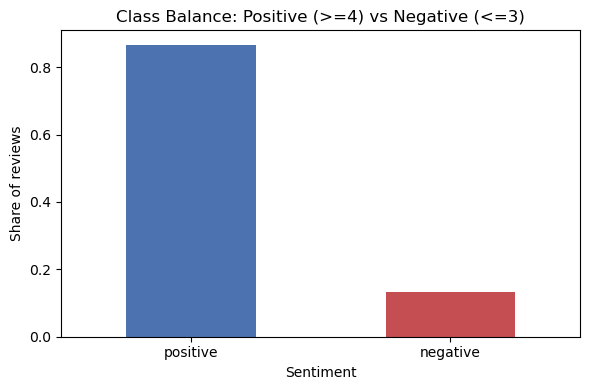

In [ ]:
# Drop the column if it exists in the dataframe
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

#Drop duplicate reviews
initial_len = len(df)
df = df.drop_duplicates(subset=['rating', 'text']).copy()
print(f"Removed {initial_len - len(df)} duplicate records.")

#Binary target mapping
df["sentiment"] = (df["rating"] >= 4).astype(int)

#Class balance calculation & visualization
import os
os.makedirs("Report/images", exist_ok=True)
os.makedirs("Report/tables", exist_ok=True)

balance = df["sentiment"].value_counts(normalize=True).rename({0: "negative", 1: "positive"})
print("Class Balance:\n", balance)

plt.figure(figsize=(6, 4))
balance.plot(kind="bar", color=['#4C72B0', '#C44E52'])
plt.title("Class Balance: Positive (>=4) vs Negative (<=3)")
plt.ylabel("Share of reviews")
plt.xlabel("Sentiment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Report/images/class_balance.png", dpi=150)
plt.show()


Note: in last year's Movies & TV version of this assignment the split was roughly 82k positive vs 19.6k negative (~81/19). Check whether CDs & Vinyl shows a similarly skewed distribution — if so, say explicitly in the report that this affects your choice of evaluation metric later (prefer F1 / balanced accuracy over raw accuracy) and possibly your modeling choice (class_weight="balanced").

## 2. Preprocessing & Analysis

To determine appropriate review inclusion criteria, we audited the dataset for empty inputs, punctuation- or emoji-only entries, and extremely short texts.

We removed the completely empty and punctuation-only records because they contribute zero linguistic or semantic value, while retaining short reviews of two or fewer words since succinct feedback like "great album" carries strong, unambiguous polarity.

Text cleaning was then performed by unescaping HTML entities, removing HTML tags, stripping URLs, removing emojis, lowercasing, and eliminating digits and punctuation. These normalization steps strip non-semantic markup and structural artifacts without destroying sentiment signals, while stemming and lemmatization were intentionally avoided at this stage to preserve subtle morphological distinctions for subsequent vocabulary frequency analysis and bag-of-words representations.

In [5]:
empty_mask = df["text"].isna() | (df["text"].str.strip() == "")
punct_only_mask = df["text"].fillna("").str.fullmatch(r"[\W_]*")
short_mask = df["text"].fillna("").str.split().str.len() <= 2

print("Empty reviews:", empty_mask.sum())
print("Punctuation/emoji-only reviews:", punct_only_mask.sum())
print("Reviews with <=2 words:", short_mask.sum())

# Remove empty and punctuation-only reviews as they carry no textual semantic value.
# Keep reviews with <= 2 words (e.g., "Great album", "Waste money") if they carry clear sentiment polarity.
df_clean = df.loc[~empty_mask & ~punct_only_mask].copy()
print(f"Total reviews retained: {len(df_clean)} out of {len(df)}")


Empty reviews: 6
Punctuation/emoji-only reviews: 34
Reviews with <=2 words: 2039
Total reviews retained: 47163 out of 47197


In [6]:
def clean_text_hybrid(text: str) -> str:
    text = str(text)
    #Unescape HTML entities (converts &quot; -> ", &amp; -> &, etc.)
    text = html.unescape(text)
    #Strip HTML tags like <br />, <div>
    text = re.sub(r"<.*?>", " ", text)
    #Strip URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    #Remove emojis cleanly using emoji library
    text = emoji.replace_emoji(text, replace=" ")
    #Lowercase
    text = text.lower()
    #Normalize contractions (prevent 's' and 't' floating tokens)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s", "", text)
    text = re.sub(r"'m", " am", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    #Strip non-alphabet characters
    text = re.sub(r"[^a-z\s]", " ", text)
    #Collapse whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["clean_text"] = df_clean["text"].apply(clean_text_hybrid)
df_clean["tokens"] = df_clean["clean_text"].str.split()
df_clean.head()


,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,sentiment,clean_text,tokens
0,5.0,Love music,This was a gift for someone,B00N1F0BKK,B00N1F0BKK,AGSRCBGM3T7IQE3CQRFF6346JHSA,1539921682876,0,True,1,this was a gift for someone,"[this, was, a, gift, for, someone]"
1,2.0,Recording quailiy is dissapointing,I am in love with the album of Uria Heep.<br /...,B07MNV5ZXN,B07MNV5ZXN,AEPA6ATLYCE57DCCN3GQTQAAZU6A,1668565115999,0,True,0,i am in love with the album of uria heep one o...,"[i, am, in, love, with, the, album, of, uria, ..."
2,5.0,Unique,Not every artist in the music Biz just wants t...,B000TP5TEI,B000TP5TEI,AFG4ELVNGCXLB36QB5WNPNFZE2QA,1303014201000,1,True,1,not every artist in the music biz just wants t...,"[not, every, artist, in, the, music, biz, just..."
3,5.0,Five Stars,"excellent product, thank you very much.",B000ELJACO,B000ELJACO,AF6DEMZC4G5OJD2SZLOOF6VFTTYA,1412044018000,0,True,1,excellent product thank you very much,"[excellent, product, thank, you, very, much]"
4,4.0,Italian Angel,"This Italian Beauty has a wonderful,Angelic & ...",B000UZ4C36,B000UZ4C36,AGXR7APN2FJYIWTJT3E2LUB2GFCQ,1286731853000,0,True,1,this italian beauty has a wonderful angelic op...,"[this, italian, beauty, has, a, wonderful, ang..."


Number of reviews: 47163
Average words per review: 81.00
Number of unique words: 70094


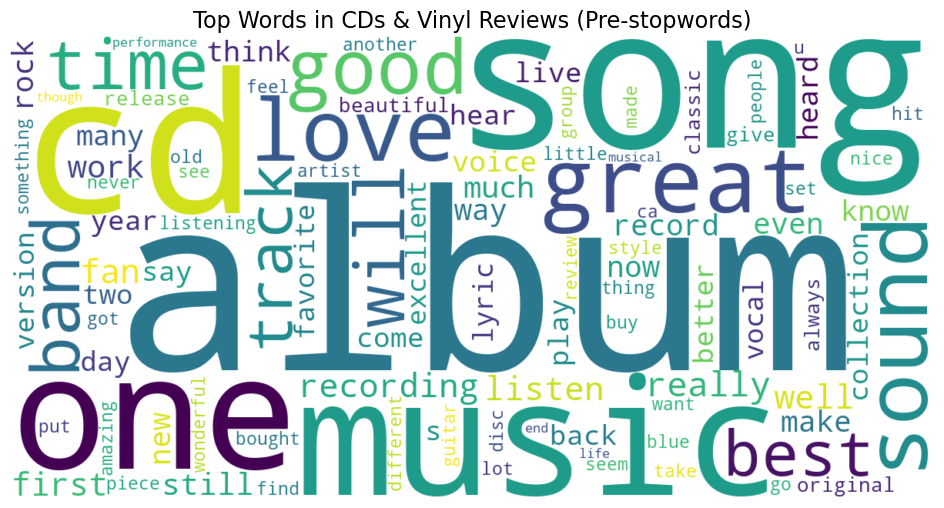

In [ ]:
n_reviews = len(df_clean)
avg_words = df_clean["tokens"].str.len().mean()
all_tokens = [w for toks in df_clean["tokens"] for w in toks]
unique_words = len(set(all_tokens))

print(f"Number of reviews: {n_reviews}")
print(f"Average words per review: {avg_words:.2f}")
print(f"Number of unique words: {unique_words}")

# WordCloud visualization from Team 4
wc_text = ' '.join(all_tokens[:200000])  # sample to speed up rendering
wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=100).generate(wc_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in CDs & Vinyl Reviews (Pre-stopwords)", fontsize=16)
plt.savefig("Report/images/wordcloud_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Bag-of-Words Model & Mutual Information

After standardizing the text, we removed standard English stopwords using scikit-learn, extracted the 100 most frequent tokens across the remaining vocabulary, generated a binary document-term occurrence matrix, and computed the mutual information between each feature and the binary sentiment label.

Stripping high-frequency functional words isolates meaningful, content-bearing terms rather than syntactic noise.

Measuring mutual information provides an information-theoretic ranking of token relevance, allowing us to evaluate the statistical dependence of individual words on review sentiment and clearly separate domain-agnostic polarity indicators like "great" and "bad" from music-specific contextual terms like "album" and "sound".


In [8]:
#Filter stopwords
df_clean["tokens_nostop"] = df_clean["tokens"].apply(
    lambda toks: [w for w in toks if w not in ENGLISH_STOP_WORDS and len(w) > 1]
)

#Extract Top 100 most frequent terms
all_words_nostop = [w for toks in df_clean["tokens_nostop"] for w in toks]
top100 = Counter(all_words_nostop).most_common(100)
top100_words = [w for w, _ in top100]
top100_df = pd.DataFrame(top100, columns=["word", "count"])
top100_df.to_csv("Report/tables/top100_words_after_stopwords.csv", index=False)
top100_df.head(20)


,word,count
0,album,29820
1,cd,22859
2,music,20885
3,like,17804
4,great,17775
5,songs,16776
6,song,14321
7,love,12854
8,good,12802
9,just,12214


c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:58: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

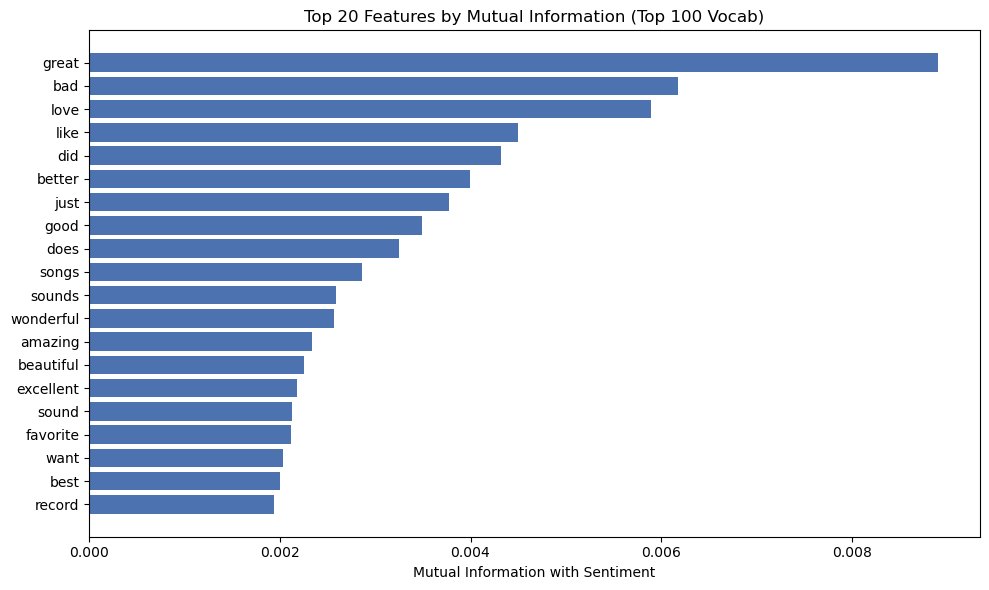

,word,mutual_information
4,great,0.008898
78,bad,0.006173
7,love,0.005897
3,like,0.004496
20,did,0.004316
22,better,0.003991
9,just,0.003773
8,good,0.003487
23,does,0.003247
5,songs,0.002863


In [9]:
#Binary feature matrix for Top 100 vocabulary
top100_vectorizer = TfidfVectorizer(vocabulary=top100_words, use_idf=False, binary=True)
X_top100 = top100_vectorizer.fit_transform(df_clean["clean_text"])

#Compute Mutual Information with sentiment
mi = mutual_info_classif(X_top100, df_clean["sentiment"], discrete_features=True, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"word": top100_words, "mutual_information": mi}).sort_values(
    "mutual_information", ascending=False
)
mi_df.to_csv("Report/tables/top100_mutual_information.csv", index=False)

#Plot Top 20 Mutual Information words for the report
plt.figure(figsize=(10, 6))
plt.barh(mi_df["word"].head(20)[::-1], mi_df["mutual_information"].head(20)[::-1], color="#4C72B0")
plt.xlabel("Mutual Information with Sentiment")
plt.title("Top 20 Features by Mutual Information (Top 100 Vocab)")
plt.tight_layout()
plt.savefig("Report/images/top20_mutual_information.png", dpi=150)
plt.show()

mi_df.head(20)


## 4. Feature Representation

All models from here on use **one stratified 80/20 train/test split** of `df_clean`, fixed below.
Everything that learns from data (IDF weights, our own Word2Vec, the classifiers) is fitted on the
training reviews only, so the test set stays untouched until final evaluation (Task 6 reuses
`train_idx` / `test_idx`).

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

y = df_clean["sentiment"].to_numpy()
texts = df_clean["clean_text"].to_numpy()

train_idx, test_idx = train_test_split(np.arange(len(df_clean)), test_size=0.2,
                                       random_state=RANDOM_STATE, stratify=y)
y_tr, y_te = y[train_idx], y[test_idx]
print(f"train: {len(train_idx)} reviews ({y_tr.mean():.1%} positive) | "
      f"test: {len(test_idx)} reviews ({y_te.mean():.1%} positive)")

def scores(y_true, y_pred, name):
    # Accuracy alone is misleading at ~87% positives, so we always report macro F1,
    # balanced accuracy and how well the minority (negative) class is found.
    return {"model": name,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, average="macro"),
            "neg_precision": precision_score(y_true, y_pred, pos_label=0),
            "neg_recall": recall_score(y_true, y_pred, pos_label=0)}

train: 37730 reviews (86.6% positive) | test: 9433 reviews (86.6% positive)


### TF-IDF (top-100 vocabulary) + Logistic Regression
Each of the 100 most frequent non-stopwords from Task 3 is one feature. We fit the model once with
default class weights and once with `class_weight="balanced"`, which re-weights errors on the
minority (negative) class.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(vocabulary=top100_words)
X_tfidf_tr = tfidf_vectorizer.fit_transform(texts[train_idx])   # IDF learned on training reviews only
X_tfidf_te = tfidf_vectorizer.transform(texts[test_idx])

tfidf_results = []
tfidf_models = {}
for cw in [None, "balanced"]:
    name = f"TF-IDF top-100 + LR (class_weight={cw})"
    lr = LogisticRegression(max_iter=1000, class_weight=cw, random_state=RANDOM_STATE)
    lr.fit(X_tfidf_tr, y_tr)
    pred = lr.predict(X_tfidf_te)
    tfidf_models[cw] = lr
    tfidf_results.append(scores(y_te, pred, name))
    print(name)
    print(classification_report(y_te, pred, target_names=["negative", "positive"], digits=3))

lr_tfidf = tfidf_models["balanced"]
tfidf_results_df = pd.DataFrame(tfidf_results).round(3)
tfidf_results_df.to_csv("Report/tables/tfidf_lr_results.csv", index=False)
tfidf_results_df

TF-IDF top-100 + LR (class_weight=None)
              precision    recall  f1-score   support

    negative      0.484     0.049     0.089      1261
    positive      0.871     0.992     0.928      8172

    accuracy                          0.866      9433
   macro avg      0.678     0.521     0.508      9433
weighted avg      0.819     0.866     0.816      9433

TF-IDF top-100 + LR (class_weight=balanced)
              precision    recall  f1-score   support

    negative      0.231     0.749     0.353      1261
    positive      0.941     0.616     0.745      8172

    accuracy                          0.634      9433
   macro avg      0.586     0.682     0.549      9433
weighted avg      0.846     0.634     0.692      9433



,model,accuracy,balanced_accuracy,macro_f1,neg_precision,neg_recall
0,TF-IDF top-100 + LR (class_weight=None),0.866,0.521,0.508,0.484,0.049
1,TF-IDF top-100 + LR (class_weight=balanced),0.634,0.682,0.549,0.231,0.749


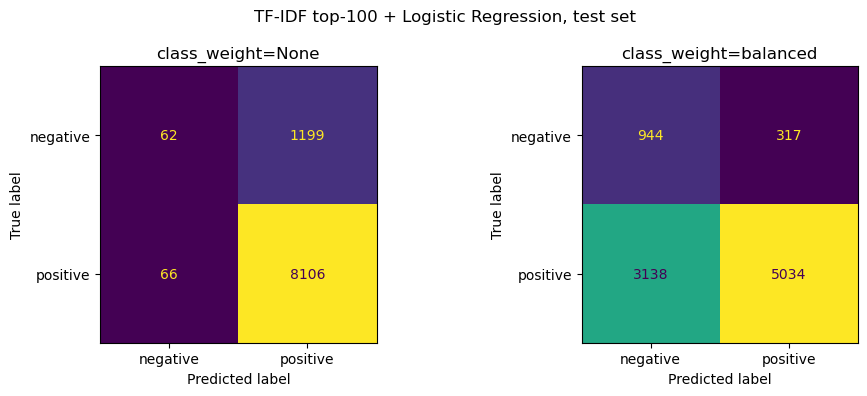

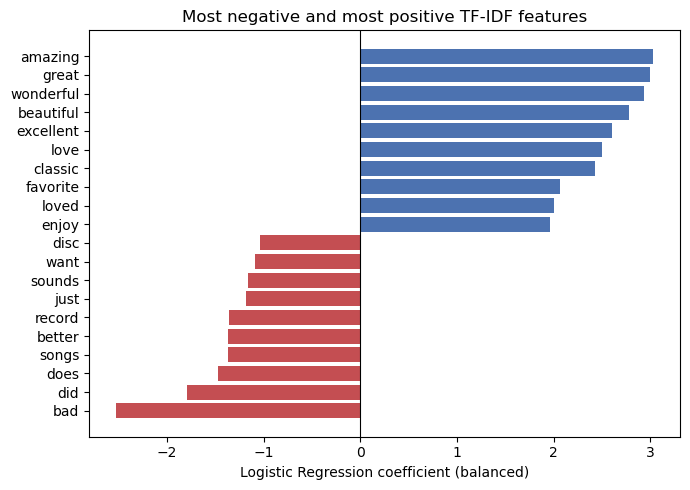

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cw in zip(axes, [None, "balanced"]):
    ConfusionMatrixDisplay.from_estimator(tfidf_models[cw], X_tfidf_te, y_te, ax=ax, colorbar=False,
                                          display_labels=["negative", "positive"])
    ax.set_title(f"class_weight={cw}")
plt.suptitle("TF-IDF top-100 + Logistic Regression, test set")
plt.tight_layout()
plt.savefig("Report/images/tfidf_lr_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

# Which of the 100 words push a review towards positive / negative?
coef = pd.Series(lr_tfidf.coef_[0], index=tfidf_vectorizer.get_feature_names_out()).sort_values()
top_coef = pd.concat([coef.head(10), coef.tail(10)])
plt.figure(figsize=(7, 5))
plt.barh(top_coef.index, top_coef.values, color=["#C44E52"] * 10 + ["#4C72B0"] * 10)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Logistic Regression coefficient (balanced)")
plt.title("Most negative and most positive TF-IDF features")
plt.tight_layout()
plt.savefig("Report/images/tfidf_lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

**Results.** Without class weighting the model predicts almost only "positive": 86.6% accuracy, but only 4.9% of negative reviews are found (macro F1 0.508). With `class_weight="balanced"` negative recall rises to 74.9% (balanced accuracy 0.682, macro F1 0.549) at the cost of many false alarms. Strongest negative features are *bad*, *did* and *does*; the latter two are what remains of *didn't/doesn't* after "not" is removed as a stopword. Full discussion: report section 4.

### Word2Vec: own model vs. pretrained
* **Own model**: trained on the *training* reviews only, on the full token lists (`tokens`, i.e.
  **with** stopwords). The brief asks for the original text, and keeping stopwords keeps negations
  ("not", "no", "never") and the local context Word2Vec learns from. Skip-gram (`sg=1`) is used because
  it handles infrequent words better than CBOW on a corpus of this size.
* **Pretrained model**: `word2vec-google-news-300` (Mikolov et al., 2013), 3M-word vocabulary (we load the 500k most frequent words), 300 dimensions,
  trained on about 100B words of Google News.

In [13]:
from gensim.models import Word2Vec
import gensim.downloader as gensim_api

w2v_own = Word2Vec(sentences=df_clean["tokens"].iloc[train_idx].tolist(),
                   vector_size=100, window=5, min_count=5, sg=1, epochs=10,
                   workers=1, seed=RANDOM_STATE)   # workers=1: multi-threaded training is not reproducible
print("Own model vocabulary:", len(w2v_own.wv.key_to_index))

# ~1.6 GB download on first use, cached in ~/gensim-data afterwards.
# The full model (3M words x 300 dims) needs ~3.6 GB RAM, doubled by most_similar(), which crashes an
# 8 GB laptop. We therefore load only the 500,000 most frequent words.
from gensim.models import KeyedVectors
PRETRAINED_LIMIT = 500_000
w2v_pre = KeyedVectors.load_word2vec_format(gensim_api.load("word2vec-google-news-300", return_path=True),
                                            binary=True, limit=PRETRAINED_LIMIT)
print("Pretrained vocabulary (loaded):", len(w2v_pre.key_to_index))

Own model vocabulary: 18466
Pretrained vocabulary (loaded): 500000


In [14]:
# Google News is case-sensitive ("Beatles", "Dylan") while our tokens are lowercased, so for the
# pretrained model we look up each corpus word as-is, then Capitalized, then UPPERCASE.
corpus_counts = Counter(w for toks in df_clean["tokens"] for w in toks)
total_tokens = sum(corpus_counts.values())

def pretrained_key(w):
    for cand in (w, w.capitalize(), w.upper()):
        if cand in w2v_pre.key_to_index:
            return cand
    return None

lookup_own = {w: w for w in corpus_counts if w in w2v_own.wv.key_to_index}
lookup_pre_exact = {w: w for w in corpus_counts if w in w2v_pre.key_to_index}
lookup_pre = {w: k for w in corpus_counts if (k := pretrained_key(w)) is not None}

def coverage(lookup):
    return len(lookup) / len(corpus_counts), sum(corpus_counts[w] for w in lookup) / total_tokens

coverage_df = pd.DataFrame(
    [("Own (CDs & Vinyl)", *coverage(lookup_own)),
     ("Pretrained, exact lookup", *coverage(lookup_pre_exact)),
     ("Pretrained, case-insensitive lookup", *coverage(lookup_pre))],
    columns=["model", "type_coverage", "token_coverage"]).round(3)
coverage_df.to_csv("Report/tables/w2v_vocabulary_coverage.csv", index=False)
print(coverage_df.to_string(index=False))

missing_pre = [(w, c) for w, c in corpus_counts.most_common() if w not in lookup_pre][:20]
missing_own = [(w, c) for w, c in corpus_counts.most_common() if w not in lookup_own][:20]
print("\nMost frequent corpus words missing from Google News:", missing_pre)
print("Most frequent corpus words missing from our own model:", missing_own)

                              model  type_coverage  token_coverage
                  Own (CDs & Vinyl)          0.263           0.976
           Pretrained, exact lookup          0.472           0.869
Pretrained, case-insensitive lookup          0.669           0.990

Most frequent corpus words missing from Google News: [('mccartney', 214), ('didnt', 121), ('doesnt', 99), ('isnt', 87), ('linkin', 79), ('listenings', 76), ('szell', 67), ('barbirolli', 64), ('recomend', 62), ('reccomend', 58), ('wasnt', 50), ('depeche', 49), ('solti', 48), ('videoid', 46), ('excelente', 45), ('aint', 44), ('bizkit', 44), ('oistrakh', 44), ('mcguinn', 40), ('arrau', 39)]
Most frequent corpus words missing from our own model: [('steiner', 46), ('korngold', 36), ('herrmann', 23), ('diabelli', 21), ('tubby', 20), ('melvins', 20), ('zassimova', 20), ('alagna', 18), ('tz', 18), ('gheorghiu', 18), ('wieland', 17), ('weissenberg', 17), ('deljavan', 17), ('waxman', 16), ('lehrer', 16), ('guster', 15), ('dando', 1

In [15]:
# Nearest neighbours for general sentiment words and music/format-specific words
probes = ["great", "terrible", "boring", "vinyl", "pressing", "remaster", "scratched", "skips", "jazz", "beatles"]
rows = []
for w in probes:
    own = ", ".join(n for n, _ in w2v_own.wv.most_similar(w, topn=5)) if w in w2v_own.wv else "(not in vocab)"
    pre = ", ".join(n for n, _ in w2v_pre.most_similar(lookup_pre[w], topn=5)) if w in lookup_pre else "(not in vocab)"
    rows.append({"word": w, "own_model": own, "pretrained": pre})
neighbours_df = pd.DataFrame(rows)
neighbours_df.to_csv("Report/tables/w2v_nearest_neighbours.csv", index=False)
pd.set_option("display.max_colwidth", 90)
neighbours_df

,word,own_model,pretrained
0,great,"fantastic, wonderful, terrific, good, excelent","terrific, fantastic, tremendous, wonderful, good"
1,terrible,"horrible, awful, fake, bad, poor","horrible, horrendous, dreadful, awful, horrid"
2,boring,"repetitive, dull, monotonous, hokey, uninteresting","dull, uninteresting, monotonous, bored, bland"
3,vinyl,"pressing, lp, gatefold, turntable, pressed","vinyl_LP, Vinyl, vinyls, gram_vinyl, vinyl_albums"
4,pressing,"vinyl, defect, equipment, remaster, mastering","pressed, Pressing, pushing, vexing, urgent"
5,remaster,"reissue, remastering, remastered, remasters, mastering","remastering, remastered, remasters, newly_remastered, remastered_versions"
6,scratched,"damaged, worn, turntable, warped, examined","scratches, scratch, Scratched, bruise, Scratches"
7,skips,"skipped, scratches, skipping, scratched, defect","skipped, skipping, misses, avoids, cancels"
8,jazz,"messengers, fusion, latin, blues, bluegrass","jazz_blues, jazz_funk, jazz_musicians, saxophonist, jazz_fusion"
9,beatles,"kinks, gt, pepper, nirvana, sgt","Fab_Four, Beatle, Rolling_Stones, Led_Zeppelin, Jimi_Hendrix"


### Word embeddings → document embeddings
Each review is the average of the vectors of its known words (zero vector if none). We compare plain mean pooling with an IDF-weighted mean, for both models, using 5-fold stratified CV (macro F1) of a scaled, balanced Logistic Regression on the training set only.

In [16]:
idf_vectorizer = TfidfVectorizer(token_pattern=r"\S+", lowercase=False)   # same tokens as df_clean["tokens"]
idf_vectorizer.fit(texts[train_idx])
idf_weight = dict(zip(idf_vectorizer.get_feature_names_out(), idf_vectorizer.idf_))
default_idf = idf_vectorizer.idf_.max()   # words unseen in training are treated as rarest

def document_embedding(tokens, kv, lookup, weighting="mean"):
    known = [w for w in tokens if w in lookup]
    if not known:
        return np.zeros(kv.vector_size)
    vecs = kv[[lookup[w] for w in known]]
    if weighting == "idf":
        return np.average(vecs, axis=0, weights=[idf_weight.get(w, default_idf) for w in known])
    return vecs.mean(axis=0)

doc_tokens = df_clean["tokens"].tolist()
doc_embeddings = {}
for model_name, kv, lookup in [("own", w2v_own.wv, lookup_own), ("pretrained", w2v_pre, lookup_pre)]:
    for weighting in ["mean", "idf"]:
        doc_embeddings[(model_name, weighting)] = np.vstack(
            [document_embedding(t, kv, lookup, weighting) for t in doc_tokens]).astype(np.float32)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
probe_clf = Pipeline([("scale", StandardScaler()),
                      ("lr", LogisticRegression(max_iter=2000, class_weight="balanced"))])
rows = []
for (model_name, weighting), X in doc_embeddings.items():
    cv_f1 = cross_val_score(probe_clf, X[train_idx], y_tr, cv=skf, scoring="f1_macro", n_jobs=-1)
    rows.append({"embedding": model_name, "pooling": weighting, "dims": X.shape[1],
                 "cv_macro_f1_mean": cv_f1.mean(), "cv_macro_f1_std": cv_f1.std()})
embedding_choice_df = pd.DataFrame(rows).round(4).sort_values("cv_macro_f1_mean", ascending=False)
embedding_choice_df.to_csv("Report/tables/w2v_embedding_choice_cv.csv", index=False)
embedding_choice_df

,embedding,pooling,dims,cv_macro_f1_mean,cv_macro_f1_std
2,pretrained,mean,300,0.6964,0.0028
0,own,mean,100,0.6875,0.0050
1,own,idf,100,0.6822,0.0034
3,pretrained,idf,300,0.6817,0.0028


In [17]:
# Final representation used in Tasks 5-7
CHOSEN = ("own", "mean")
w2v_chosen = w2v_own.wv if CHOSEN[0] == "own" else w2v_pre
X_doc_embeddings = doc_embeddings[CHOSEN]
VECTOR_SIZE = X_doc_embeddings.shape[1]
X_doc_tr, X_doc_te = X_doc_embeddings[train_idx], X_doc_embeddings[test_idx]
print("Chosen:", CHOSEN, X_doc_embeddings.shape)

Chosen: ('own', 'mean') (47163, 100)


**Choice: own model + mean pooling.** Pretrained scores slightly higher in CV (0.696 vs 0.688 macro F1), but the gap is small, and our own model captures domain meanings (*pressing* → vinyl, defect; pretrained: pushing, urgent), is 3x smaller and keeps the pickled model light. IDF weighting was worse for both models. Full comparison: report section 4.

## 5. Feature Selection & Dimensionality Reduction
We project the **word** embeddings of our own Word2Vec model (all words in its vocabulary) to 2D with PCA
and with FastICA, then plot a hand-picked set of words from five groups so that we can check whether
related words land near each other.

PCA: variance explained by 2 components: [0.071 0.063] total 0.134


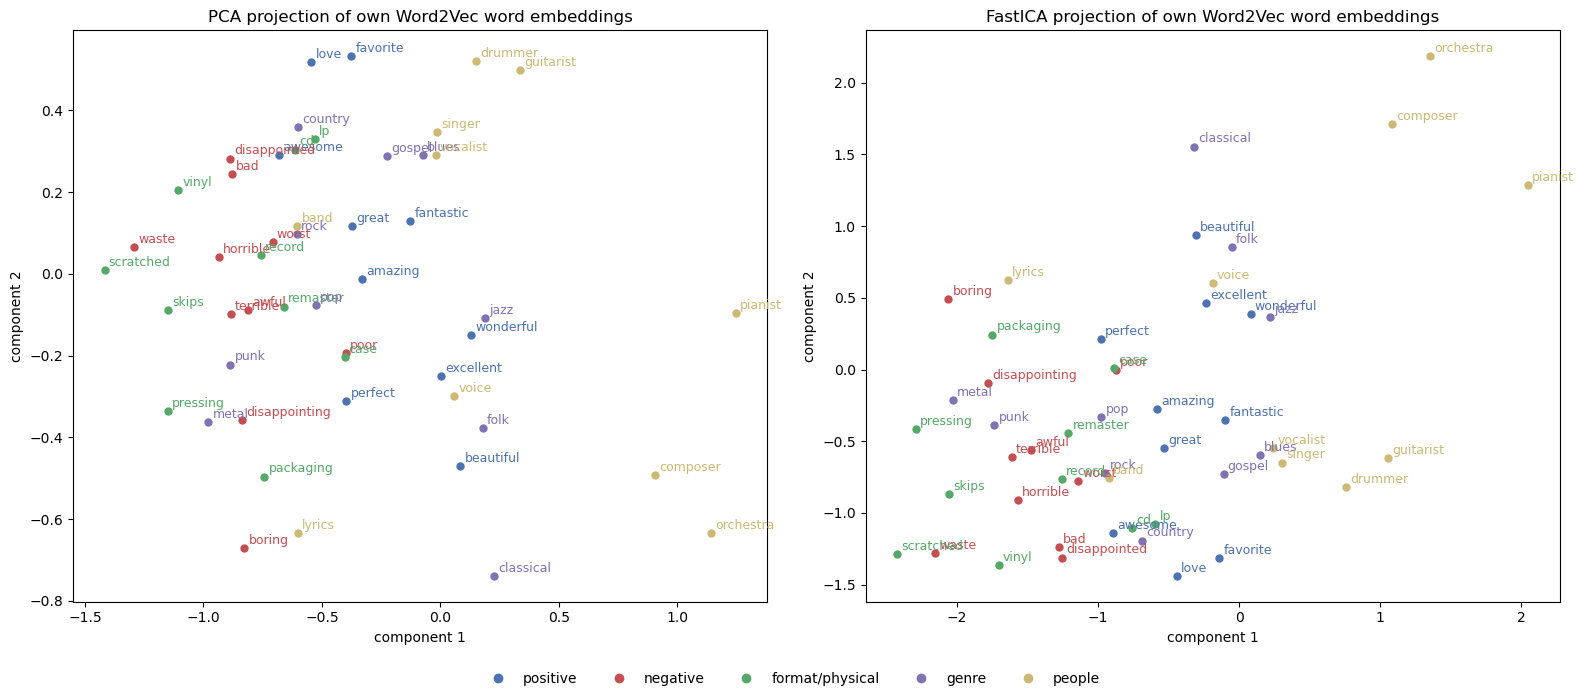

In [18]:
words = list(w2v_own.wv.index_to_key)
word_vectors = w2v_own.wv.vectors

pca = PCA(n_components=2, random_state=RANDOM_STATE)
word_vectors_pca = pca.fit_transform(word_vectors)
print("PCA: variance explained by 2 components:", pca.explained_variance_ratio_.round(3),
      "total", pca.explained_variance_ratio_.sum().round(3))

ica = FastICA(n_components=2, random_state=RANDOM_STATE, max_iter=1000)
word_vectors_ica = ica.fit_transform(word_vectors)

word_groups = {
    "positive":       ["great", "excellent", "amazing", "wonderful", "awesome", "fantastic", "love", "beautiful", "perfect", "favorite"],
    "negative":       ["bad", "terrible", "awful", "horrible", "boring", "worst", "disappointed", "poor", "waste", "disappointing"],
    "format/physical":["vinyl", "cd", "lp", "record", "pressing", "remaster", "packaging", "case", "scratched", "skips"],
    "genre":          ["jazz", "rock", "metal", "classical", "blues", "country", "pop", "punk", "folk", "gospel"],
    "people":         ["singer", "band", "guitarist", "drummer", "vocalist", "orchestra", "pianist", "composer", "voice", "lyrics"],
}
plot_words = [(w, g) for g, ws in word_groups.items() for w in ws if w in w2v_own.wv.key_to_index]
idx = [w2v_own.wv.key_to_index[w] for w, _ in plot_words]
palette = dict(zip(word_groups, ["#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"]))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, coords, title in [(axes[0], word_vectors_pca, "PCA"), (axes[1], word_vectors_ica, "FastICA")]:
    pts = coords[idx]
    for (w, g), (x, y_) in zip(plot_words, pts):
        ax.scatter(x, y_, color=palette[g], s=25)
        ax.annotate(w, (x, y_), fontsize=9, xytext=(3, 3), textcoords="offset points", color=palette[g])
    ax.set_title(f"{title} projection of own Word2Vec word embeddings")
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=g) for g, c in palette.items()]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.savefig("Report/images/w2v_pca_ica.png", dpi=150, bbox_inches="tight")
plt.show()

To back up the visual impression with numbers, we check (a) how well each 2D projection keeps the
**10 nearest neighbours** a word has in the full 100-dimensional space (for the 2,000 most frequent words),
and (b) for the five groups above, whether words are closer to their own group than to the other groups,
both in the original space (cosine similarity) and in each 2D projection.

In [19]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

def neighbour_preservation(high, low, k=10):
    nn_high = NearestNeighbors(n_neighbors=k + 1, metric="cosine").fit(high).kneighbors(return_distance=False)[:, 1:]
    nn_low = NearestNeighbors(n_neighbors=k + 1).fit(low).kneighbors(return_distance=False)[:, 1:]
    return np.mean([len(set(a) & set(b)) / k for a, b in zip(nn_high, nn_low)])

top_n = 2000
proj_rows = []
for name, coords in [("PCA", word_vectors_pca), ("FastICA", word_vectors_ica)]:
    proj_rows.append({
        "projection": name,
        "kNN_preserved@10 (top-2000 words)": neighbour_preservation(word_vectors[:top_n], coords[:top_n]),
        "silhouette of 5 word groups (2D)": silhouette_score(coords[idx], [g for _, g in plot_words]),
    })
proj_rows.append({
    "projection": "original 100-D (cosine)",
    "kNN_preserved@10 (top-2000 words)": 1.0,
    "silhouette of 5 word groups (2D)": silhouette_score(normalize(word_vectors[idx]), [g for _, g in plot_words], metric="cosine"),
})
projection_quality_df = pd.DataFrame(proj_rows).round(3)
projection_quality_df.to_csv("Report/tables/pca_ica_projection_quality.csv", index=False)
print(projection_quality_df.to_string(index=False))

# Example pairs: cosine similarity in 100-D vs. distance rank in each 2D projection
def rank_in_2d(coords, a, b):
    ia, ib = w2v_own.wv.key_to_index[a], w2v_own.wv.key_to_index[b]
    d = np.linalg.norm(coords[:top_n] - coords[ia], axis=1)
    return int((d < np.linalg.norm(coords[ib] - coords[ia])).sum())   # how many of the top-2000 words are closer
pairs = [("great", "excellent"), ("terrible", "awful"), ("vinyl", "lp"), ("scratched", "skips"),
         ("jazz", "blues"), ("great", "terrible")]
pairs_df = pd.DataFrame([{"pair": f"{a} / {b}",
                          "cosine_100D": round(float(w2v_own.wv.similarity(a, b)), 3),
                          "rank_of_b_near_a_PCA": rank_in_2d(word_vectors_pca, a, b),
                          "rank_of_b_near_a_ICA": rank_in_2d(word_vectors_ica, a, b)} for a, b in pairs])
pairs_df.to_csv("Report/tables/pca_ica_word_pairs.csv", index=False)
pairs_df

             projection  kNN_preserved@10 (top-2000 words)  silhouette of 5 word groups (2D)
                    PCA                              0.032                            -0.105
                FastICA                              0.032                            -0.105
original 100-D (cosine)                              1.000                             0.268


,pair,cosine_100D,rank_of_b_near_a_PCA,rank_of_b_near_a_ICA
0,great / excellent,0.710,973,968
1,terrible / awful,0.742,13,13
2,vinyl / lp,0.732,497,490
3,scratched / skips,0.684,5,5
4,jazz / blues,0.679,328,341
5,great / terrible,0.462,1043,1009


**Discussion.** Some near-synonyms stay close (*terrible/awful*, *scratched/skips*), but 2D keeps only 13.4% of the variance and 3% of each word's 10 nearest neighbours, and *great/excellent* end up far apart. PCA and FastICA give the same picture: with 2 components FastICA only rotates the PCA-whitened axes. Full discussion: report section 5.

## 6. Modeling & Evaluation
Train KNN, Naive Bayes and Logistic Regression on the Word2Vec **document** representations.

Multinomial Naive Bayes requires non-negative features and cannot be used directly on
embeddings (which contain negative values). We use `GaussianNB` instead — TODO: justify
this choice explicitly in the report (assumes features are roughly normally distributed per
class, which is a reasonable approximation for averaged embeddings, unlike raw counts).


In [28]:
#Same split as Task 4
X_tr, X_te = X_doc_tr, X_doc_te

print("Training shape:", X_tr.shape)
print("Test shape:", X_te.shape)
print("Training positive proportion:", y_tr.mean())
print("Test positive proportion:", y_te.mean())

Training shape: (37730, 100)
Test shape: (9433, 100)
Training positive proportion: 0.866260270341903
Test positive proportion: 0.8663203646771971


In [30]:
#Evaluation metrics

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "negative_recall": "recall_macro"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [31]:
# Models

models = {
    "KNN": Pipeline([("scale", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=15))]),
    "GaussianNB": Pipeline([("clf", GaussianNB())]),
    "LogisticRegression": Pipeline([("scale", StandardScaler()),("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}

In [ ]:
#Cross validation
cv_results = []
cv_fold_results = {}
for name, model in models.items():
    scores_cv = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_fold_results[name] = scores_cv
    cv_results.append({
        "model": name,
        "cv_macro_f1_mean": scores_cv["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores_cv["test_macro_f1"].std(),
    })

#Display results 
cv_results_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1_mean",ascending=False).round(4)
print("\nWord2Vec classifier cross-validation results:")
display(cv_results_df)


Word2Vec classifier cross-validation results:


,model,cv_macro_f1_mean,cv_macro_f1_std
2,LogisticRegression,0.6483,0.0095
0,KNN,0.6231,0.0062
1,GaussianNB,0.4265,0.0046


In [38]:
#Final test-set evaluation

test_results = []

for name, model in models.items():

    # Fit model on the complete training set
    model.fit(X_tr, y_tr)

    # Predict the untouched test set
    y_pred = model.predict(X_te)

    print(f"\n{name}")
    print(classification_report(
        y_te,
        y_pred,
        target_names=["negative", "positive"],
        digits=3
    ))

    test_results.append({
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro")
    })

test_results_df = pd.DataFrame(test_results).round(4)

print("\nFinal test-set results:")
display(test_results_df)


KNN
              precision    recall  f1-score   support

    negative      0.608     0.176     0.273      1261
    positive      0.885     0.983     0.931      8172

    accuracy                          0.875      9433
   macro avg      0.747     0.579     0.602      9433
weighted avg      0.848     0.875     0.843      9433


GaussianNB
              precision    recall  f1-score   support

    negative      0.174     0.850     0.289      1261
    positive      0.943     0.379     0.541      8172

    accuracy                          0.442      9433
   macro avg      0.558     0.615     0.415      9433
weighted avg      0.840     0.442     0.507      9433


LogisticRegression
              precision    recall  f1-score   support

    negative      0.642     0.226     0.334      1261
    positive      0.891     0.981     0.934      8172

    accuracy                          0.880      9433
   macro avg      0.767     0.603     0.634      9433
weighted avg      0.858     0.880    

,model,accuracy,balanced_accuracy,macro_f1
0,KNN,0.8747,0.5793,0.6023
1,GaussianNB,0.4422,0.6147,0.4152
2,LogisticRegression,0.8797,0.6033,0.6341


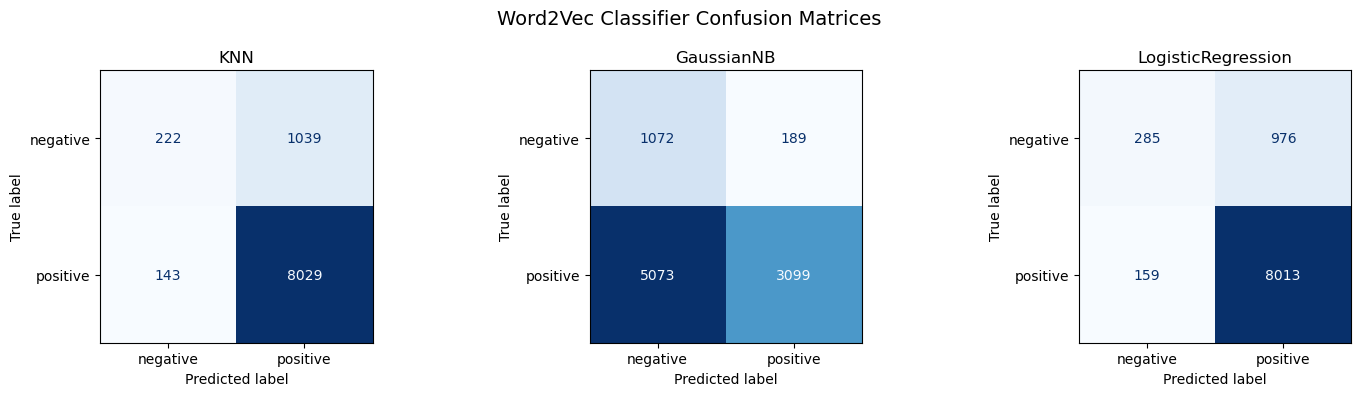

In [ ]:
# Confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):

    model.fit(X_tr, y_tr)

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_te,
        y_te,
        display_labels=["negative", "positive"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(name)

plt.suptitle(
    "Word2Vec Classifier Confusion Matrices",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "Report/images/w2v_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Hyperparameter search on Logistic Regression

**Important — read this before reporting a number.** The score `GridSearchCV` reports
internally (`.best_score_`) is itself a cross-validated estimate used to *pick* the
hyperparameters. It is not the number you report as your final model's performance —
report that on the held-out test set instead, evaluated once, after the search is done.


In [41]:
lr_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__class_weight": [None, "balanced"],
}

grid = GridSearchCV(lr_pipeline,
                     param_grid=param_grid, 
                     scoring="f1_macro", 
                     cv=cv, 
                     n_jobs=-1)
grid.fit(X_tr, y_tr)

print("Best params:", grid.best_params_)
print("Best CV F1 (search score, NOT your final reported score):", grid.best_score_)

best_lr = grid.best_estimator_
test_preds = best_lr.predict(X_te)
print("\nHeld-out test set performance (THIS is what you report as final):")
print(classification_report(y_te, test_preds))


Best params: {'clf__C': 1, 'clf__class_weight': 'balanced'}
Best CV F1 (search score, NOT your final reported score): 0.6875043122602177

Held-out test set performance (THIS is what you report as final):
              precision    recall  f1-score   support

           0       0.36      0.82      0.50      1261
           1       0.97      0.77      0.86      8172

    accuracy                           0.78      9433
   macro avg       0.66      0.80      0.68      9433
weighted avg       0.88      0.78      0.81      9433



### Save the best-performing model
The deliverable requires a single pickled `Pipeline` containing the fitted vectorizer/scaler
*and* the fitted model, so it can predict directly from raw text. TODO: decide whether your
best model is the TF-IDF+LR from Task 4 or the Word2Vec+LR from this task, and build the
matching Pipeline — a raw `LogisticRegression` object alone is not sufficient.


In [43]:
# Save the best Word2Vec Logistic Regression model

with open("Team-20.pickle", "wb") as f:
    pickle.dump(best_lr, f)

# Load it back
with open("Team-20.pickle", "rb") as f:
    loaded_model = pickle.load(f)

print("Loaded model:", loaded_model)

# Test prediction on an already-created Word2Vec document embedding
sample_embedding = document_embedding(
    clean_text_hybrid(
        "This album is absolutely amazing, best purchase ever"
    ).split(),
    w2v_own.wv,
    lookup_own
).reshape(1, -1)

print("Prediction:", loaded_model.predict(sample_embedding))

Loaded model: Pipeline(steps=[('scale', StandardScaler()),
                ('clf',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=2000,
                                    random_state=42))])
Prediction: [1]


## 7. Clustering & Topic Modeling

### Agglomerative Clustering & DBSCAN on Word2Vec word embeddings


In [23]:
# Use a manageable sample of word vectors (or all of them if small enough)
sample_size = min(2000, len(word_vectors))
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(word_vectors), size=sample_size, replace=False)
word_vectors_sample = word_vectors[sample_idx]
words_sample = [words[i] for i in sample_idx]

agg = AgglomerativeClustering(n_clusters=10)
agg_labels = agg.fit_predict(word_vectors_sample)

dbscan = DBSCAN(eps=0.5, min_samples=5)  # TODO: tune eps via a k-distance plot, don't guess
dbscan_labels = dbscan.fit_predict(word_vectors_sample)

print("Agglomerative cluster sizes:", np.bincount(agg_labels))
print("DBSCAN cluster count (excl. noise):", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("DBSCAN noise points:", (dbscan_labels == -1).sum())


Agglomerative cluster sizes: [486 152 348 142 120  55  74 228 102 293]
DBSCAN cluster count (excl. noise): 0
DBSCAN noise points: 2000


**TODO — inspect a handful of clusters** (print the words in 3-4 clusters from each
method) and discuss whether they correspond to something meaningful (sentiment, genre,
format-related terms like "vinyl"/"CD"/"turntable", etc).

### Topic Modeling — BERTopic and FuzzyTM

Two practical notes from the assignment brief:
- BERTopic downloads a sentence-transformer model on first use, and accepts precomputed
  embeddings — you can hand it your own Word2Vec/TF-IDF document embeddings instead of
  letting it fetch its default model, which avoids the download entirely if network access
  is a problem.
- FuzzyTM builds dense vocabulary x document matrices and will exhaust an ordinary laptop's
  memory on the full review vocabulary. Prune rare words before fitting it, and **report the
  threshold you used** — this is explicitly asked for.


In [24]:
from bertopic import BERTopic

# Passing precomputed embeddings avoids BERTopic downloading its own sentence-transformer.
docs = df_clean["clean_text"].tolist()
topic_model = BERTopic(embedding_model=None)  # TODO: confirm this signature against your BERTopic version
topics, probs = topic_model.fit_transform(docs, embeddings=X_doc_embeddings)

topic_model.get_topic_info().head(10)


c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OSError: [WinError 127] The specified procedure could not be found. Error loading "c:\Users\e99ku\anaconda3\envs\AML\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [ ]:
# FuzzyTM — prune the vocabulary first to avoid exhausting memory.
MIN_DOC_FREQ = 20  # TODO: justify this threshold, tune if needed, and report the final value used
word_freq = Counter(w for toks in df_clean["tokens_nostop"] for w in set(toks))
pruned_vocab = {w for w, c in word_freq.items() if c >= MIN_DOC_FREQ}
print(f"Vocabulary pruned from {len(word_freq)} to {len(pruned_vocab)} words (min_doc_freq={MIN_DOC_FREQ})")

# TODO: fit FuzzyTM on the pruned corpus. Consider running this step on a subsample of
# reviews too if memory is still an issue even after pruning.


**TODO — evaluate topic quality with an appropriate metric** (e.g. topic coherence,
topic diversity) for both BERTopic and FuzzyTM, and compare them.


## 8. Evaluation & Discussion

**TODO** — pull together, in prose, referencing the tables/figures produced above:
- Which representation (TF-IDF vs Word2Vec-own vs Word2Vec-pretrained) and which classifier
  performed best, with numbers.
- Why you think that happened (dataset size, vocabulary characteristics, class imbalance).
- Limitations of your approach (e.g. mean-pooling loses word order, small training set for
  your own Word2Vec, DBSCAN's sensitivity to `eps`, FuzzyTM's memory constraints).
- Concrete ideas for improvement (e.g. transformer-based embeddings, weighted document
  embeddings, more thorough hyperparameter search, addressing class imbalance directly).
